In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
for target in ["train-00000-of-00001", "dev-00000-of-00001", "test-00000-of-00001"]:
    file_path = f"data/{target}.parquet"
    df = pd.read_parquet(file_path)

    print(f"{target}: {len(df):,} rows")
    print()

train-00000-of-00001: 557,367 rows

dev-00000-of-00001: 6,572 rows

test-00000-of-00001: 6,601 rows



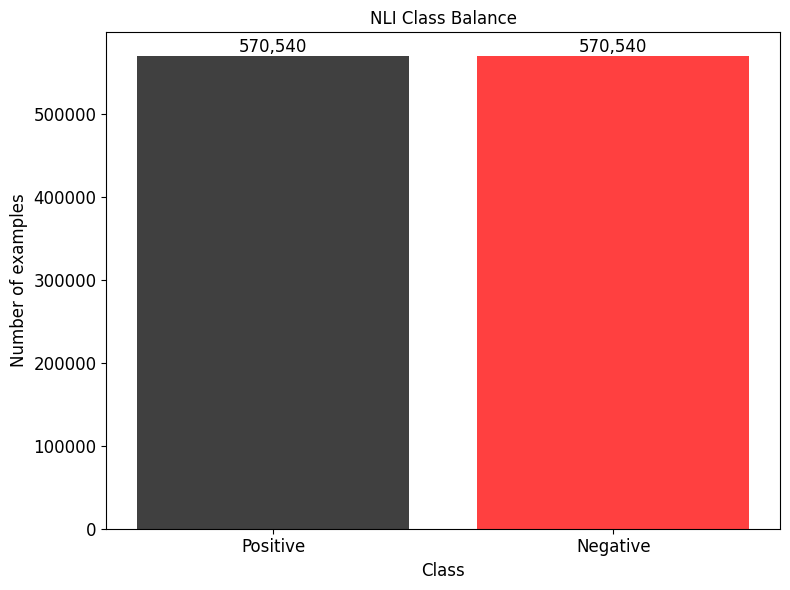

In [ ]:
# Number of triplets in each target
train_size = 557_367
dev_size = 6_572
test_size = 6_601

# Total number of triplets
total = train_size + dev_size + test_size

# Each triplet creates one positive and one negative pair
positive = total
negative = total

# Plot
labels = ["Positive", "Negative"]
counts = [positive, negative]

plt.figure(figsize=(8, 6))

bars = plt.bar(
    labels,
    counts,
    color=["black", "red"],
    alpha = 0.75
)

plt.title("NLI Class Balance", fontsize=12)
plt.xlabel("Class", fontsize=12)
plt.ylabel("Number of examples", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.tight_layout()

plt.savefig("block3_nli_class_balance.png", dpi=300)
plt.show()

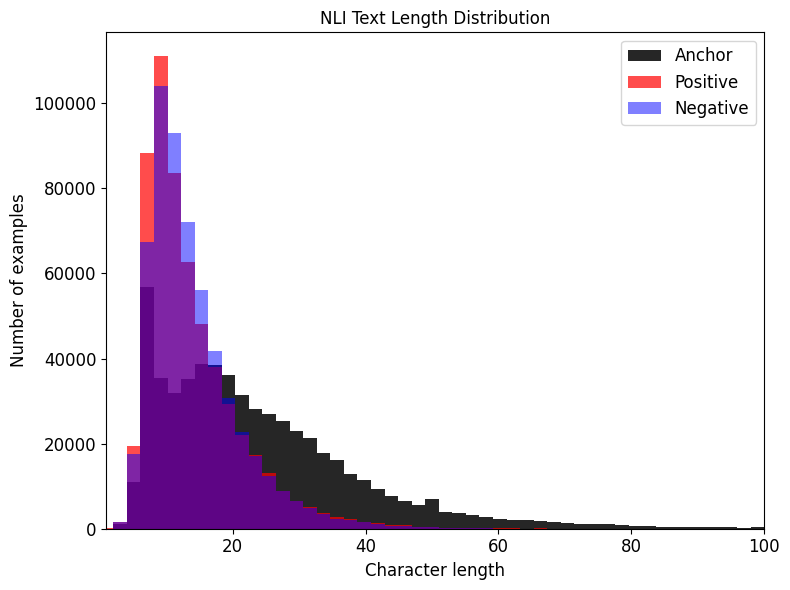

In [7]:
train = pd.read_parquet("data/train-00000-of-00001.parquet")
dev = pd.read_parquet("data/dev-00000-of-00001.parquet")
test = pd.read_parquet("data/test-00000-of-00001.parquet")

df = pd.concat([train, dev, test], ignore_index=True)

anchor_lengths = df["anchor"].str.len()
positive_lengths = df["positive"].str.len()
negative_lengths = df["negative"].str.len()

bins = np.linspace(0, 100, 50) 

plt.figure(figsize=(8, 6))

plt.hist(
    anchor_lengths,
    bins=bins,
    alpha=0.85,
    label="Anchor",
    color="black"
)

plt.hist(
    positive_lengths,
    bins=bins,
    alpha=0.7,
    label="Positive",
    color="red"
)

plt.hist(
    negative_lengths,
    bins=bins,
    alpha=0.5,
    label="Negative",
    color="blue"
)

plt.title("NLI Text Length Distribution", fontsize=12)
plt.xlabel("Character length", fontsize=12)
plt.ylabel("Number of examples", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)

plt.xlim(1,100)

plt.tight_layout()

plt.savefig("block3_nli_text_length.png", dpi=300)
plt.show()

In [9]:
files = {
    "train": "data/train-00000-of-00001.parquet",
    "dev": "data/dev-00000-of-00001.parquet",
    "test": "data/test-00000-of-00001.parquet"
}
datasets = []

for target, path in files.items():
    df = pd.read_parquet(path)
    df["target"] = target
    datasets.append(df)

data = pd.concat(datasets, ignore_index=True)

text_columns = ["anchor", "positive", "negative"]

#1. Null Values
print("\n1. Null values")
print(data[text_columns].isnull().sum())

#2. Empty Values
print("\n2. Empty Values")

for column in text_columns:
    empty = data[column].fillna("").str.strip().eq("").sum()
    print(f"{column}: {empty:,}")

#3. Duplicate Rows
print("\n3. Duplicate Rows")

duplicates = data.duplicated(subset=text_columns).sum()
print(f"Duplicate rows: {duplicates:,}")

#4. Alternate Data
print("\n4. Alternate Data")

for column in text_columns:
    non_strings = (~data[column].isna()) & (~data[column].apply(lambda x: isinstance(x, str)))
    print(f"{column}: {non_strings.sum():,} non-string values")

#5. Missing/Extra Columns
print("\n5. Columns")

expected_columns = ["anchor", "positive", "negative", "target"]
print("Actual columns:  ", list(data.columns))
print("Expected columns:", expected_columns)

unexpected_columns = [
    column for column in data.columns
    if column not in expected_columns
]

print("Unexpected columns:", unexpected_columns)

#Duplicate Anchors
print("\n6. DUPLICATE ANCHORS")

duplicate_anchors = data["anchor"].duplicated().sum()
print(f"Repeated anchor values: {duplicate_anchors:,}")


1. Null values
anchor      0
positive    0
negative    0
dtype: int64

2. Empty Values
anchor: 1
positive: 0
negative: 0

3. Duplicate Rows
Duplicate rows: 3,349

4. Alternate Data
anchor: 0 non-string values
positive: 0 non-string values
negative: 0 non-string values

5. Columns
Actual columns:   ['anchor', 'positive', 'negative', 'target']
Expected columns: ['anchor', 'positive', 'negative', 'target']
Unexpected columns: []

6. DUPLICATE ANCHORS
Repeated anchor values: 279,815
